#Q1

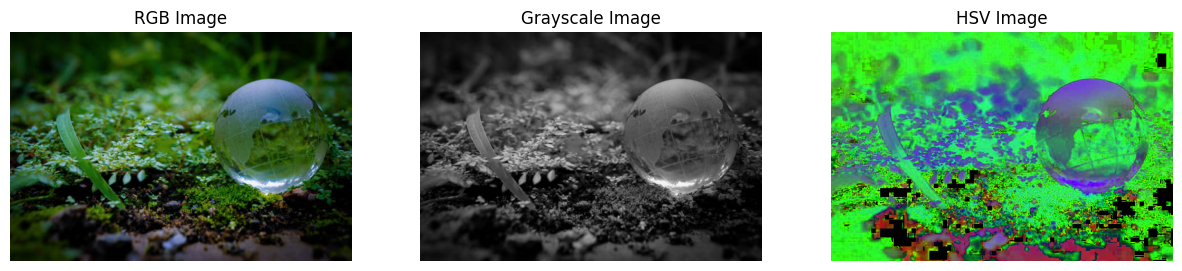

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread("sample1.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV Image")
plt.axis("off")

plt.show()


OpenCV uses the BGR color format for historical and performance reasons, as early image processing libraries and camera hardware stored color data in this order. Internally, OpenCV is optimized for BGR, and conversion to RGB is only required for visualization purposes.

#Q2

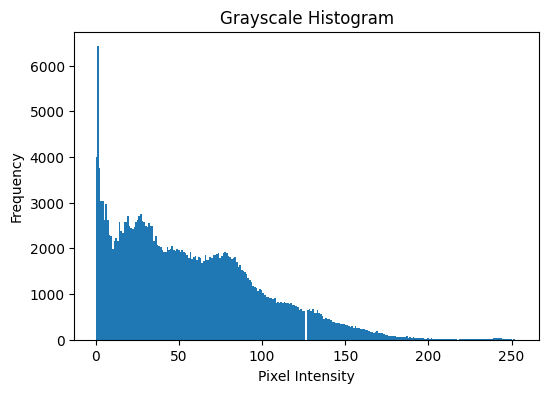

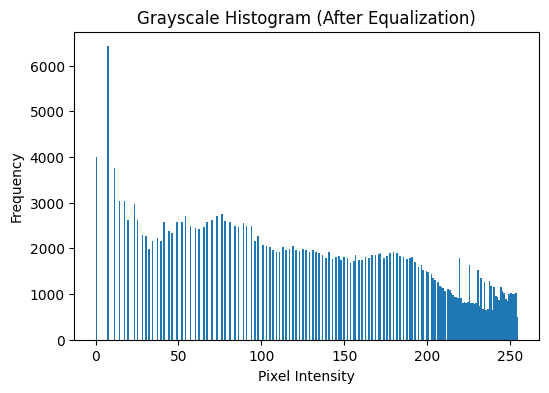

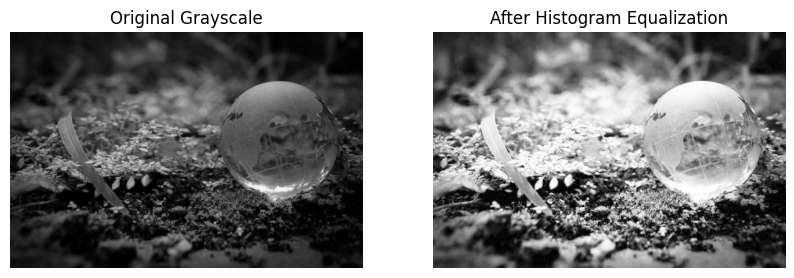

In [15]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize = (6,4))
plt.hist(gray.ravel(), bins = 256)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()
equalized = cv2.equalizeHist(gray)
plt.figure(figsize=(6,4))
plt.hist(equalized.ravel(), bins=256)
plt.title("Grayscale Histogram (After Equalization)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap="gray")
plt.title("After Histogram Equalization")
plt.axis("off")

plt.show()




1.  After histogram equalization, the image shows improved contrast, with darker regions becoming more distinguishable and details in low-contrast areas becoming clearer.
2.   Histogram equalization is not useful for images that already have good contrast or for images where local contrast matters more than global contrast, such as images with uneven lighting or natural photographs where brightness variations are meaningful.



#Q3

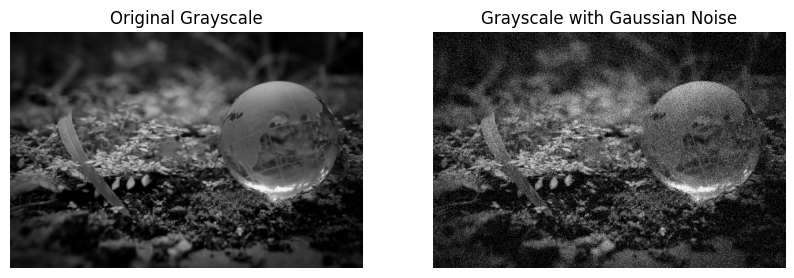

In [16]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#GAUSSIAN NOISE
noise = np.random.normal(0, 25, gray.shape)
noisy_image = gray + noise
noisy_image = np.clip(noisy_image, 0, 255)
noisy_image = noisy_image.astype(np.uint8)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy_image, cmap="gray")
plt.title("Grayscale with Gaussian Noise")
plt.axis("off")

plt.show()


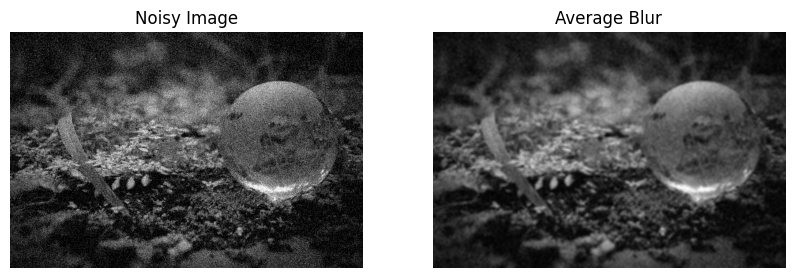

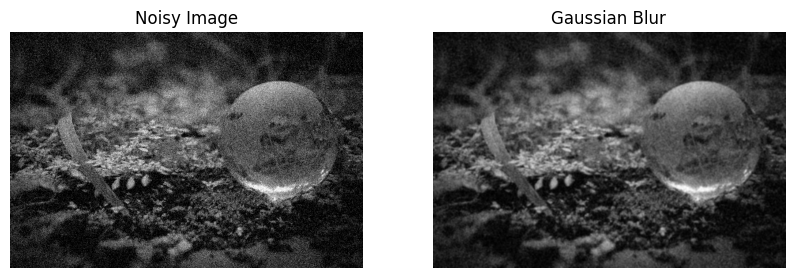

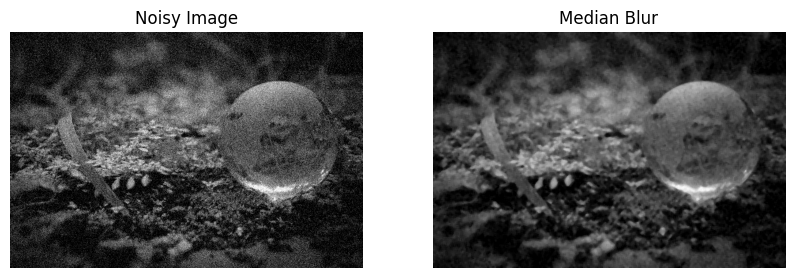

In [17]:
avg_blur = cv2.blur(noisy_image, (5, 5))
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(avg_blur, cmap="gray")
plt.title("Average Blur")
plt.axis("off")

plt.show()
gaussian_blur = cv2.GaussianBlur(noisy_image, (5, 5), 0)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gaussian_blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

median_blur = cv2.medianBlur(noisy_image, 5)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(median_blur, cmap="gray")
plt.title("Median Blur")
plt.axis("off")

plt.show()

1. The median filter handled noise best, especially impulse noise, because it replaces each pixel with the median of its neighborhood, effectively removing outlier values without averaging them.
2. The median filter preserved edges better than average and Gaussian filters because it does not blur across intensity boundaries and maintains sharp transitions in the image

#Q4

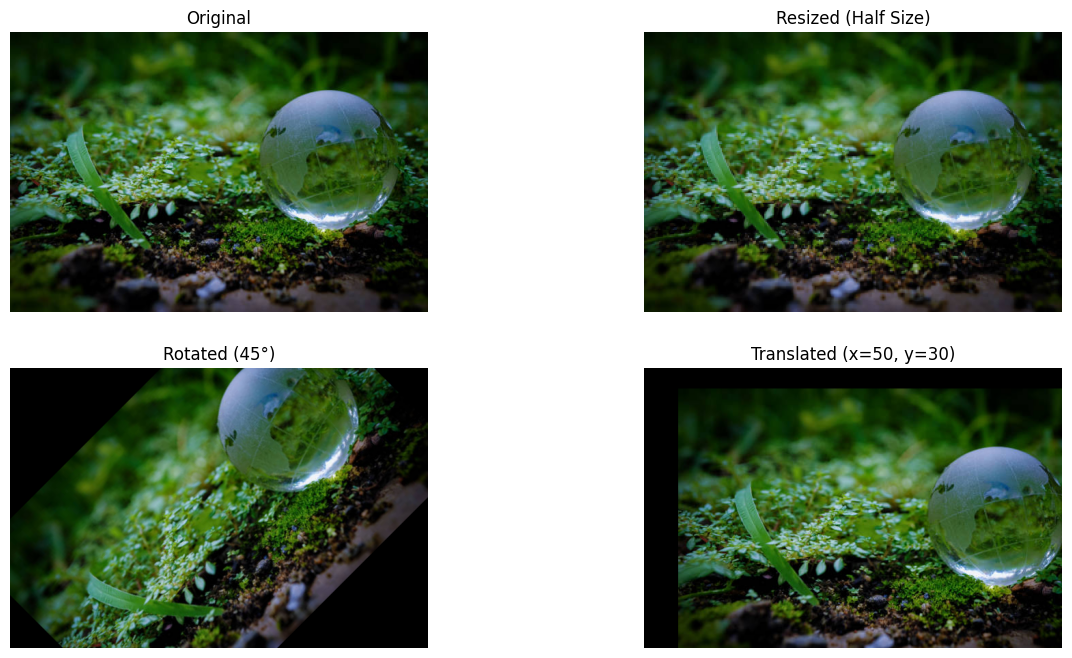

In [18]:
height, width = image.shape[:2]

resized = cv2.resize(image,(width // 2, height // 2),interpolation=cv2.INTER_AREA)
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(
    center=center,
    angle=45,
    scale=1.0
)
rotated = cv2.warpAffine(
    image,
    rotation_matrix,
    (width, height)
)
T = np.float32([
    [1, 0, 50],   # shift right by 50
    [0, 1, 30]    # shift down by 30
])
translated = cv2.warpAffine(
    image,
    T,
    (width, height)
)
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized (Half Size)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated (45°)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
plt.title("Translated (x=50, y=30)")
plt.axis("off")

plt.show()



Geometric transformations move pixels to new locations, and some areas in the output image no longer correspond to any pixel from the original image. These empty regions are filled with black pixels by default, resulting in black areas.

#Q5


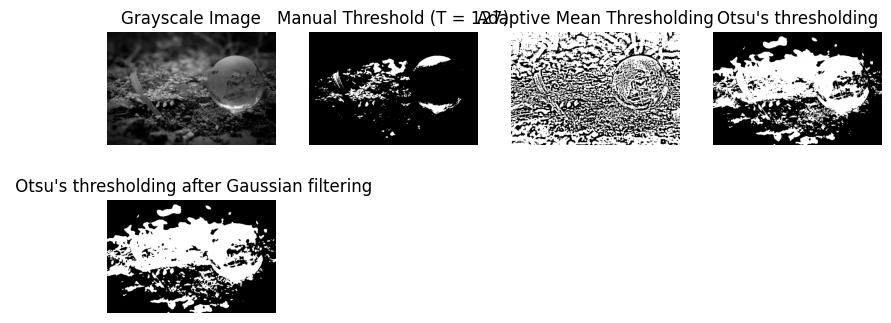

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("sample1.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
T= 127
_,binary_manual = cv2.threshold(img_gray,T,255,cv2.THRESH_BINARY)
plt.figure(figsize=(10,4))

plt.subplot(2,4,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(binary_manual, cmap='gray')
plt.title(f"Manual Threshold (T = {T})")
plt.axis('off')

# Corrected: Use img_gray for adaptiveThreshold and plt.imshow for display
thresh = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

plt.subplot(2,4,3)
plt.imshow(thresh, cmap='gray')
plt.title("Adaptive Mean Thresholding")
plt.axis('off')


_, th2 = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.subplot(2,4,4)
plt.imshow(th2, cmap='gray')
plt.title("Otsu's thresholding")
plt.axis('off')

# Otsu's thresholding after Gaussian filtering
blur = cv2.GaussianBlur(img_gray, (5,5), 0)
_, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.subplot(2,4,5)
plt.imshow(th3, cmap='gray')
plt.title(" Otsu's thresholding after Gaussian filtering")
plt.axis('off')
plt.show()

1. Otsu’s method automatically computes an optimal global threshold by analyzing the image histogram and minimizing intra-class variance between foreground and background. This removes human guesswork and adapts the threshold to the actual intensity distribution of the image, making it more reliable than manual global thresholding. Compared to adaptive thresholding, Otsu provides a cleaner segmentation when the image has a clear foreground–background contrast and relatively uniform illumination.
2. Global thresholding fails badly when the image has non-uniform lighting conditions, such as:

Shadows or gradients in illumination

Uneven background brightness

Scanned documents with faded or dark regions

#Q6

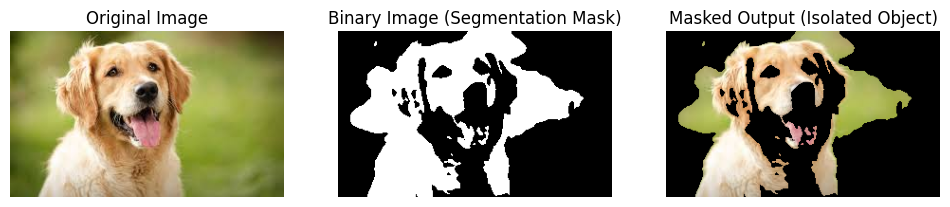

In [20]:
img = cv2.imread("sample2.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Otsu's thresholding after Gaussian filtering
blur = cv2.GaussianBlur(img_gray, (5,5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
masked = cv2.bitwise_and(img_rgb, img_rgb, mask=binary)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image (Segmentation Mask)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(masked)
plt.title("Masked Output (Isolated Object)")
plt.axis('off')

plt.show()


Thresholding acts as segmentation by classifying pixels into foreground and background based on their intensity values.
The resulting binary image serves as a segmentation mask that identifies the region of interest.
Applying this mask to the original image selectively retains foreground pixels while suppressing the background.
Thus, thresholding separates an image into meaningful regions using simple intensity-based decisions.

#Q7

1. Smoothing reduces noise and small intensity fluctuations in the image.
This prevents isolated noisy pixels from being incorrectly classified during thresholding.
As a result, thresholding produces a cleaner and more stable binary segmentation.
2. HSV separates color information (Hue) from brightness (Value).
This makes segmentation more robust to lighting changes compared to RGB, where color and intensity are mixed.
Using HSV allows objects to be segmented based on color alone, independent of illumination.
3. Yes, histogram equalization can negatively affect thresholding.
It redistributes pixel intensities globally, which may merge or distort foreground and background intensity distributions.
4. OpenCV’s built-in functions are highly optimized and implemented in low-level languages like C++.
They execute much faster than Python pixel loops and are less error-prone.
Using built-in functions also ensures consistency, efficiency, and better utilization of hardware acceleration.